In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('/content/datos_tratados.csv')
df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado,cuentas_diarias
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,...,No,Sí,Sí,No,Anual,Yes,Cheque enviado por correo,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,...,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.9,542.40,1.996667
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,...,Sí,No,No,No,Mensual,Yes,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,...,Sí,No,Sí,Sí,Mensual,Yes,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,...,No,Sí,Sí,No,Mensual,Yes,Cheque enviado por correo,83.9,267.40,2.796667


In [3]:
df.columns

Index(['id', 'Churn', 'genero', 'tiene +60', 'posee_pareja',
       'posee_dependientes', 'tiempo_contrato', 'servicio_telefono',
       'multiples_lineas', 'tipo_internet', 'seguridad_online',
       'backup_online', 'proteccion_dispositivo', 'soporte_tecnico',
       'streaming_tv', 'streaming_peliculas', 'tipo_contrato',
       'factura_digital', 'metodo_pago', 'valor_mensal', 'total_cobrado',
       'cuentas_diarias'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7032 non-null   object 
 1   Churn                   7032 non-null   object 
 2   genero                  7032 non-null   object 
 3   tiene +60               7032 non-null   int64  
 4   posee_pareja            7032 non-null   object 
 5   posee_dependientes      7032 non-null   object 
 6   tiempo_contrato         7032 non-null   int64  
 7   servicio_telefono       7032 non-null   object 
 8   multiples_lineas        7032 non-null   object 
 9   tipo_internet           7032 non-null   object 
 10  seguridad_online        7032 non-null   object 
 11  backup_online           7032 non-null   object 
 12  proteccion_dispositivo  7032 non-null   object 
 13  soporte_tecnico         7032 non-null   object 
 14  streaming_tv            7032 non-null   

## Treatamiento de datos

In [6]:
df = df.drop(columns=['id'])

In [7]:
df

,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado,cuentas_diarias
0,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,No,...,No,Sí,Sí,No,Anual,Yes,Cheque enviado por correo,65.60,593.30,2.186667
1,No,Masculino,0,No,No,9,Sí,Sí,DSL,No,...,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.90,542.40,1.996667
2,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,No,...,Sí,No,No,No,Mensual,Yes,Cheque electrónico,73.90,280.85,2.463333
3,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,No,...,Sí,No,Sí,Sí,Mensual,Yes,Cheque electrónico,98.00,1237.85,3.266667
4,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,No,...,No,Sí,Sí,No,Mensual,Yes,Cheque enviado por correo,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,Femenino,0,No,No,13,Sí,No,DSL,Sí,...,No,Sí,No,No,Anual,No,Cheque enviado por correo,55.15,742.90,1.838333
7028,Sí,Masculino,0,Sí,No,22,Sí,Sí,Fiber optic,No,...,No,No,No,Sí,Mensual,Yes,Cheque electrónico,85.10,1873.70,2.836667
7029,No,Masculino,0,No,No,2,Sí,No,DSL,No,...,No,No,No,No,Mensual,Yes,Cheque enviado por correo,50.30,92.75,1.676667
7030,No,Masculino,0,Sí,Sí,67,Sí,No,DSL,Sí,...,Sí,Sí,No,Sí,Bienal,No,Cheque enviado por correo,67.85,4627.65,2.261667


In [12]:
cols_to_fix = [
    'seguridad_online', 'backup_online', 'proteccion_dispositivo',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

In [13]:
df.isnull().sum()

,0
id,0
Churn,0
genero,0
tiene +60,0
posee_pareja,0
posee_dependientes,0
tiempo_contrato,0
servicio_telefono,0
multiples_lineas,0
tipo_internet,0


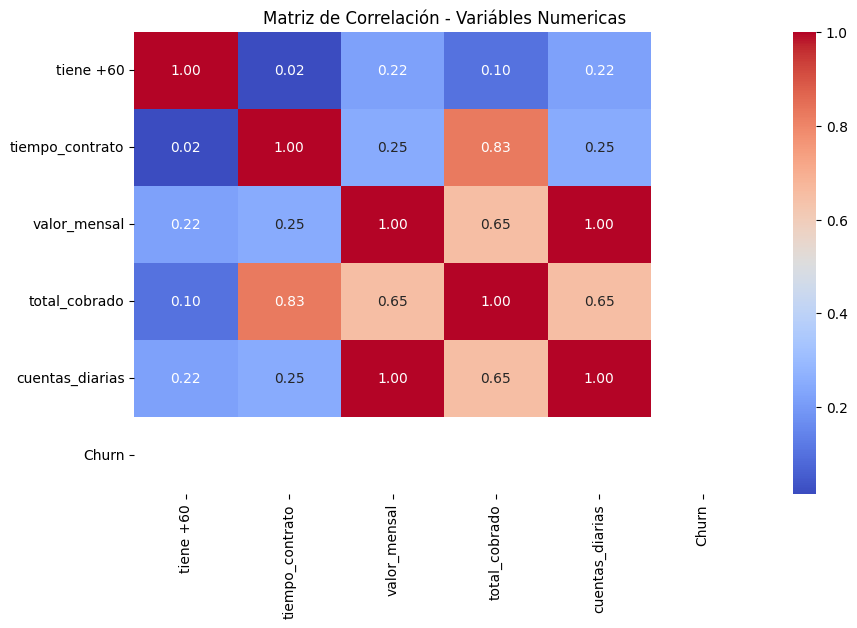

In [14]:
df_numeric = df.select_dtypes(include=["int64", "float64"])

df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

In [16]:
df = df.drop(columns=["valor_mensal","cuentas_diarias"])

In [17]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")

In [18]:
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


📌 Analisis de variable: id


Churn,No,Sí
id,,
0002-ORFBO,100.0,0.0
0003-MKNFE,100.0,0.0
0004-TLHLJ,0.0,100.0
0011-IGKFF,0.0,100.0
0013-EXCHZ,0.0,100.0
...,...,...
9987-LUTYD,100.0,0.0
9992-RRAMN,0.0,100.0
9992-UJOEL,100.0,0.0



📌 Analisis de variable: genero


Churn,No,Sí
genero,,
Femenino,73.040482,26.959518
Masculino,73.795435,26.204565



📌 Analisis de variable: posee_pareja


...

Churn,No,Sí
tipo_contrato,,
Anual,88.722826,11.277174
Bienal,97.151335,2.848665
Mensual,57.290323,42.709677



📌 Analisis de variable: factura_digital


Churn,No,Sí
factura_digital,,
No,83.624302,16.375698
Yes,66.410749,33.589251



📌 Analisis de variable: metodo_pago


Churn,No,Sí
metodo_pago,,
Cheque electrónico,54.714588,45.285412
Cheque enviado por correo,80.798005,19.201995
Tarjeta de crédito (automático),84.746877,15.253123
Transferencia bancaria (automática),83.268482,16.731518


In [20]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2